# Practical 5: Dimensionality Reduction

| Prac No | Practical Description 
|---|---|
| 5 (a) | Implement Principal Component Analysis (PCA)
| 5 (b) | Implement t-Distributed Stochastic Neighbor Embedding (t-SNE)
| 5 (c) | Implement Linear Discriminant Analysis (LDA)

## Setup — imports and global configuration

In [1]:
import numpy as np, pandas as pd, time
%matplotlib inline
import matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.datasets import load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
warnings.filterwarnings('ignore')
pd.set_option('display.width', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
RS = 42
np.random.seed(RS)

---
# 5(A) Principal Component Analysis (PCA)

### Aim
To study and implement Principal Component Analysis, to find the number of principal components required to retain the information of the dataset, and to examine the effect of the reduction on a classification model.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (PCA, StandardScaler, LogisticRegression)
- Matplotlib, Seaborn

### Theory
**Dimensionality reduction** is the process of reducing the number of features of a dataset while keeping as much of its information as possible. It is needed because of the **curse of dimensionality**: as the number of features grows, the data becomes sparse, the distances between the points become nearly equal, the model overfits, the training becomes slow and the data can no longer be visualised. Reduction is done either by **feature selection** (keeping some of the original columns) or by **feature extraction** (building a few new columns out of all the old ones). PCA, t-SNE and LDA belong to the second kind.

**Principal Component Analysis** is the most common **unsupervised, linear** method of feature extraction. It finds a new set of axes, called **principal components**, such that:

- The **first component** is the direction along which the data has the **maximum variance**.
- Every next component has the maximum remaining variance and is **orthogonal (perpendicular)** to all the earlier ones, so the new features are completely uncorrelated.

The steps of the algorithm are:

1. **Standardise** the data, so that every feature has mean 0 and variance 1.
2. Compute the **covariance matrix** of the standardised data.
3. Compute the **eigenvalues and eigenvectors** of that matrix. The eigenvectors are the directions of the new axes (the principal components) and the eigenvalue of each one is the amount of variance along it.
4. **Sort** the eigenvectors in the decreasing order of their eigenvalues and keep the first k of them.
5. **Project** the original data on these k eigenvectors to get the reduced dataset.

The importance of a component is reported by the **explained variance ratio**, which is its eigenvalue divided by the sum of all the eigenvalues. The value of k is chosen from the **cumulative explained variance** (commonly the smallest k that keeps 95% of the variance) or from the **scree plot**, by looking for the elbow.

**Scaling before PCA is compulsory.** Since PCA is driven entirely by variance, a column measured in large units would have a large variance only because of its unit and the first component would simply follow that column.

The advantages of PCA are that it removes correlated and noisy features, speeds up training, reduces overfitting and allows the data to be visualised. Its limitations are that the new components are **combinations of all the original features and so lose their physical meaning**, that it can capture only **linear** relations, and that it ignores the class labels, so the direction of the largest variance need not be the direction that separates the classes best.

---
### Implementation & Result

#### Step 1: The dataset and why scaling is needed before PCA

In [2]:
wine = load_wine()
X, y = wine.data, wine.target
print('Wine dataset : %d samples, %d features, %d classes' % (*X.shape, len(wine.target_names)))
print('\nFirst three samples (only the first six features are shown):')
print(pd.DataFrame(X, columns=wine.feature_names).iloc[:3, :6].round(2).to_string(index=False))

# --- scaling is compulsory before PCA ---
print('\nVariance of a few features BEFORE scaling:')
print(pd.Series(X.var(axis=0), index=wine.feature_names).round(2)
        .sort_values(ascending=False).head(4).to_string())
print('\n"proline" has the largest variance, so without scaling PCA would simply')
print('follow that one column. Hence StandardScaler is applied first.')

X_sc = StandardScaler().fit_transform(X)
print('\nAfter scaling, the variance of every feature is %.1f' % X_sc.var(axis=0)[0])

Wine dataset : 178 samples, 13 features, 3 classes

First three samples (only the first six features are shown):
 alcohol  malic_acid  ash  alcalinity_of_ash  magnesium  total_phenols
   14.23        1.71 2.43               15.6      127.0           2.80
   13.20        1.78 2.14               11.2      100.0           2.65
   13.16        2.36 2.67               18.6      101.0           2.80

Variance of a few features BEFORE scaling:
proline              98609.60
magnesium              202.84
alcalinity_of_ash       11.09
color_intensity          5.34

"proline" has the largest variance, so without scaling PCA would simply
follow that one column. Hence StandardScaler is applied first.

After scaling, the variance of every feature is 1.0


#### Step 2: Applying PCA and studying the explained variance

Component  Eigenvalue  Variance explained %  Cumulative %
      PC1       4.732                36.199        36.199
      PC2       2.511                19.207        55.406
      PC3       1.454                11.124        66.530
      PC4       0.924                 7.069        73.599
      PC5       0.858                 6.563        80.162
      PC6       0.645                 4.936        85.098
      PC7       0.554                 4.239        89.337
      PC8       0.350                 2.681        92.018

The first two components alone hold 55.41% of the total information.


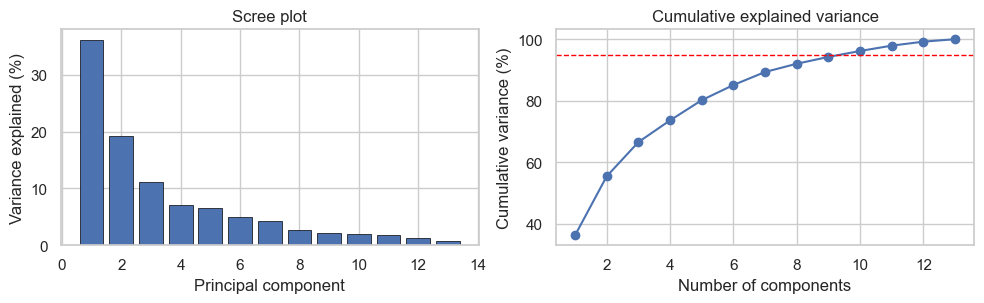

In [3]:
pca = PCA()
X_pca = pca.fit_transform(X_sc)

evr = pca.explained_variance_ratio_
table = pd.DataFrame({'Component': ['PC%d' % (i+1) for i in range(len(evr))],
                      'Eigenvalue': pca.explained_variance_,
                      'Variance explained %': 100*evr,
                      'Cumulative %': 100*np.cumsum(evr)})
print(table.head(8).round(3).to_string(index=False))
print('\nThe first two components alone hold %.2f%% of the total information.'
      % (100*evr[:2].sum()))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].bar(range(1, len(evr)+1), 100*evr, color='#4c72b0', edgecolor='black', lw=.5)
ax[0].set_xlabel('Principal component'); ax[0].set_ylabel('Variance explained (%)')
ax[0].set_title('Scree plot')
ax[1].plot(range(1, len(evr)+1), 100*np.cumsum(evr), 'o-')
ax[1].axhline(95, color='red', ls='--', lw=1)
ax[1].set_xlabel('Number of components'); ax[1].set_ylabel('Cumulative variance (%)')
ax[1].set_title('Cumulative explained variance')
plt.tight_layout(); plt.show()

#### Step 3: Projecting the data on two components and reading the loadings

Shape : (178, 13)  ->  (178, 2)  (13 features reduced to 2)


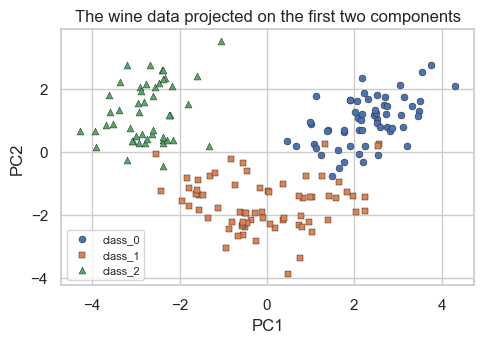

Loadings (how much each original feature contributes):
                                PC1    PC2
flavanoids                    0.423 -0.003
total_phenols                 0.395  0.065
od280/od315_of_diluted_wines  0.376 -0.164
proanthocyanins               0.313  0.039
nonflavanoid_phenols         -0.299  0.029

A principal component is a weighted combination of ALL the original features,
so PC1 is a new feature and not any one of the original columns.


In [4]:
X2 = PCA(n_components=2).fit_transform(X_sc)
print('Shape : %s  ->  %s  (13 features reduced to 2)' % (X_sc.shape, X2.shape))

plt.figure(figsize=(5, 3.6))
for c, m in zip(range(3), ['o','s','^']):
    plt.scatter(X2[y==c, 0], X2[y==c, 1], marker=m, s=25, edgecolor='k', lw=.3,
                label=wine.target_names[c])
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(fontsize=8)
plt.title('The wine data projected on the first two components')
plt.tight_layout(); plt.show()

load = pd.DataFrame(pca.components_[:2].T, columns=['PC1','PC2'], index=wine.feature_names)
print('Loadings (how much each original feature contributes):')
print(load.reindex(load['PC1'].abs().sort_values(ascending=False).index).head(5).round(3).to_string())
print('\nA principal component is a weighted combination of ALL the original features,')
print('so PC1 is a new feature and not any one of the original columns.')

#### Step 4: Choosing the number of components and the effect on a classifier

In [5]:
# --- how many components are needed for 95% of the information ---
n95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print('Components needed to keep 95%% of the variance : %d out of 13' % n95)

p95 = PCA(n_components=0.95).fit(X_sc)
X_r = p95.transform(X_sc)
print('Shape after reduction :', X_r.shape)

X_back = p95.inverse_transform(X_r)
print('Reconstruction error (mean squared) : %.4f' % ((X_sc - X_back)**2).mean())

print('\nEffect of PCA on a classifier (5-fold cross-validation):\n')
rows = []
for name, data in [('All 13 features', X_sc), ('2 components', X2),
                   ('%d components (95%%)' % n95, X_r)]:
    t = time.time()
    acc = cross_val_score(LogisticRegression(max_iter=5000), data, y, cv=5).mean()
    rows.append([name, data.shape[1], acc, time.time()-t])
print(pd.DataFrame(rows, columns=['Data used','Features','CV accuracy','Time (s)'])
        .round(4).to_string(index=False))
print('\nPCA removes the noise and the correlation between the columns, so the accuracy')
print('is kept almost unchanged with far fewer features.')

Components needed to keep 95% of the variance : 10 out of 13
Shape after reduction : (178, 10)
Reconstruction error (mean squared) : 0.0383

Effect of PCA on a classifier (5-fold cross-validation):

          Data used  Features  CV accuracy  Time (s)
    All 13 features        13       0.9889    0.0427
       2 components         2       0.9552    0.0371
10 components (95%)        10       0.9889    0.0450

PCA removes the noise and the correlation between the columns, so the accuracy
is kept almost unchanged with far fewer features.


### Observations
- Before scaling, the feature **proline had by far the largest variance**, so PCA applied to the raw data would simply have followed that one column; after StandardScaler the variance of every feature became **1.0**.
- The first principal component had an eigenvalue of **4.732 and explained 36.20% of the variance**, the second **2.511 and 19.21%**, so the **first two components together held 55.41%** of the information of all the thirteen features.
- The scree plot fell sharply for the first three components and then flattened, and the cumulative curve showed that **10 of the 13 components are needed to keep 95% of the variance**.
- The thirteen features were reduced to two, and the plot of PC1 against PC2 showed the three classes of wine already separated into three visible groups, even though the class labels were never given to PCA.
- The loadings showed that **PC1 is built mainly from flavanoids (0.423), total_phenols (0.395) and od280/od315 (0.376)**, i.e. a principal component is a weighted mixture of all the original columns and not any one of them.
- Reducing the data to 10 components gave a **reconstruction error of only 0.0383** and the cross-validated accuracy of logistic regression remained **exactly 0.9889**, the same as with all 13 features, while even **2 components still gave 0.9552**.

### Conclusion

In conclusion, Principal Component Analysis was successfully implemented on the wine dataset and the thirteen original features were reduced to a much smaller number of new, uncorrelated features. It was observed that PCA is an unsupervised linear method which builds each component as a weighted combination of all the original columns, that the components are arranged in the decreasing order of the variance they explain, and that the number of components to keep is decided from the cumulative explained variance or the scree plot. It was also observed that scaling before PCA is compulsory, and that the accuracy of the classifier remained unchanged even after removing several components, which shows that much of the original data was redundant.

---
# 5(B) t-Distributed Stochastic Neighbor Embedding (t-SNE)

### Aim
To study and implement t-SNE for the visualisation of high-dimensional data in two dimensions, to examine the effect of the perplexity parameter, and to compare t-SNE with PCA.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (TSNE, PCA, StandardScaler, load_digits)
- Matplotlib, Seaborn

### Theory
**t-SNE** is a **non-linear, unsupervised** technique used almost entirely for **visualising** high-dimensional data in two or three dimensions. PCA preserves the **global variance** of the data, so two points that are far apart stay far apart; t-SNE instead preserves the **local neighbourhood**, i.e. points that are neighbours in the original space remain neighbours in the picture. This is why t-SNE separates groups that PCA leaves overlapping.

The algorithm works in three stages:

1. **In the high-dimensional space** the distance between every pair of points is converted into a **probability of similarity** using a Gaussian distribution centred on each point. Two nearby points get a high probability and two distant points a very low one.

2. **In the low-dimensional (2-D) space** the points are placed at random and the same probabilities are computed, but here a **Student's t-distribution with one degree of freedom** is used instead of a Gaussian. Its heavy tail gives distant points more room, which prevents all the points from being squeezed into the centre — the "crowding problem".

3. The positions of the 2-D points are then moved by **gradient descent** so as to minimise the **Kullback-Leibler (KL) divergence** between the two sets of probabilities. The KL divergence printed at the end is the value of this cost, and a lower value means the picture matches the original neighbourhoods better.

The most important parameter is the **perplexity**, which is roughly the **number of neighbours** that each point takes into account. A small perplexity (about 5) shows very local detail and may break one real group into several pieces, while a large perplexity (about 50 or more) looks at the broader structure. The usual range is **5 to 50**, and the value should be smaller than the number of samples. The other parameters are the learning rate, the number of iterations (at least 250, normally 1000) and the initialisation.

Three points must be remembered while reading a t-SNE plot:

- The **axes have no meaning**; they are not components and cannot be interpreted like PC1 and PC2.
- The **distance between two clusters is not meaningful**, and the size of a cluster does not indicate its true spread.
- The result **changes from run to run** when the starting position is random, since the algorithm is a randomised optimisation.

t-SNE also has **no transform() method**: it cannot place a new, unseen point on an existing plot, so it cannot be used as a preprocessing step for a model in the way PCA can. It is also slow, roughly O(n²), which is why PCA is normally applied first to bring the data down to about 30-50 components and t-SNE is then run on that result.

---
### Implementation & Result

#### Step 1: A high-dimensional dataset and applying t-SNE

Digits dataset : 800 samples, 64 features (an 8x8 image = 64 pixels), 10 classes


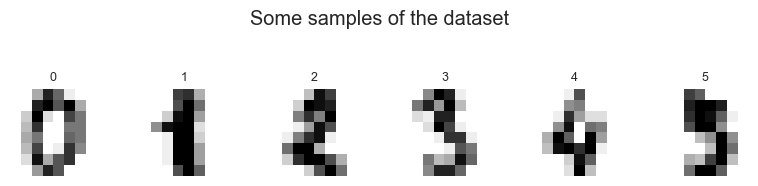


Shape : (800, 64)  ->  (800, 2)
Time taken by t-SNE : 3.32 seconds
KL divergence after optimisation : 0.5914
Number of iterations : 999


In [6]:
digits = load_digits()
Xd, yd = digits.data[:800], digits.target[:800]
print('Digits dataset : %d samples, %d features (an 8x8 image = 64 pixels), %d classes'
      % (*Xd.shape, len(set(yd))))

fig, axes = plt.subplots(1, 6, figsize=(8, 1.6))
for ax, i in zip(axes, range(6)):
    ax.imshow(digits.images[i], cmap='gray_r'); ax.set_title(str(yd[i]), fontsize=9)
    ax.axis('off')
plt.suptitle('Some samples of the dataset', y=1.15)
plt.tight_layout(); plt.show()

Xd_sc = StandardScaler().fit_transform(Xd)
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=RS)
Xd_ts = tsne.fit_transform(Xd_sc)
print('\nShape : %s  ->  %s' % (Xd_sc.shape, Xd_ts.shape))
print('Time taken by t-SNE : %.2f seconds' % (time.time()-t0))
print('KL divergence after optimisation : %.4f' % tsne.kl_divergence_)
print('Number of iterations : %d' % tsne.n_iter_)

#### Step 2: Comparing the t-SNE picture with PCA

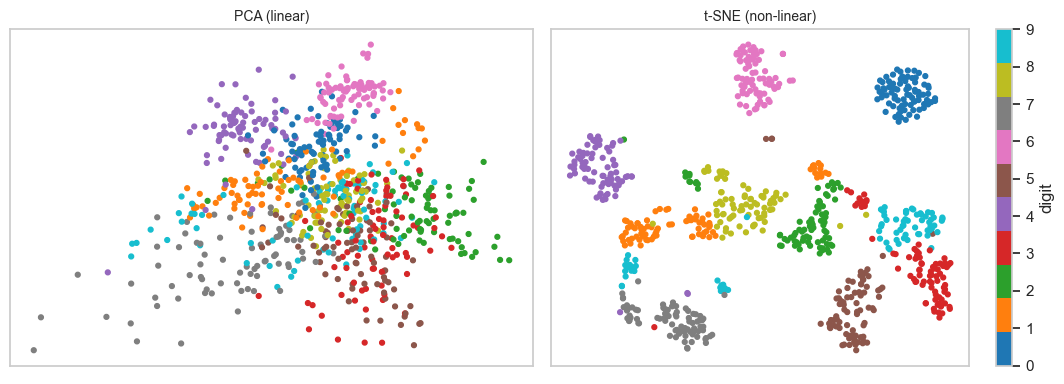

PCA only rotates the data, so the ten digits overlap heavily in two components
(the first two components hold only 22.01% of the variance).
t-SNE keeps the NEIGHBOURS of every point, so the same digits form separate
islands even though the total variance has no meaning here.


In [8]:
Xd_pca = PCA(n_components=2).fit_transform(Xd_sc)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, data, name in [(ax[0], Xd_pca, 'PCA (linear)'), (ax[1], Xd_ts, 't-SNE (non-linear)')]:
    s = a.scatter(data[:,0], data[:,1], c=yd, cmap='tab10', s=12)
    a.set_title(name, fontsize=10); a.set_xticks([]); a.set_yticks([])
plt.colorbar(s, ax=ax[1], label='digit')
plt.tight_layout(); plt.show()

print('PCA only rotates the data, so the ten digits overlap heavily in two components')
print('(the first two components hold only %.2f%% of the variance).'
      % (100*PCA(n_components=2).fit(Xd_sc).explained_variance_ratio_.sum()))
print('t-SNE keeps the NEIGHBOURS of every point, so the same digits form separate')
print('islands even though the total variance has no meaning here.')

#### Step 3: The effect of the perplexity parameter

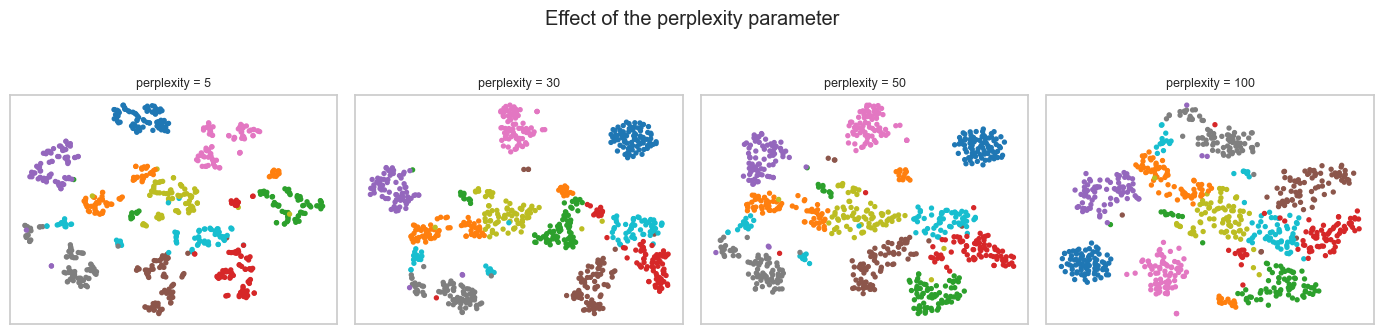

Perplexity     KL divergence     
5              0.6697            
30             0.5914            
50             0.5627            
100            0.4674            

(The KL value falls as the perplexity rises, but the values of two different
perplexities are not directly comparable, since the target distribution itself
changes with the perplexity.)

Perplexity is roughly the number of neighbours each point considers.
A small value shows very local detail (many small pieces), a large value
looks at the broader structure. The usual range is 5 to 50.


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, p in zip(axes, [5, 30, 50, 100]):
    m = TSNE(n_components=2, perplexity=p, random_state=RS).fit_transform(Xd_sc)
    ax.scatter(m[:,0], m[:,1], c=yd, cmap='tab10', s=8)
    ax.set_title('perplexity = %d' % p, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Effect of the perplexity parameter', y=1.04)
plt.tight_layout(); plt.show()

print('%-14s %-18s' % ('Perplexity', 'KL divergence'))
for p in [5, 30, 50, 100]:
    t = TSNE(n_components=2, perplexity=p, random_state=RS).fit(Xd_sc)
    print('%-14d %-18.4f' % (p, t.kl_divergence_))
print('\n(The KL value falls as the perplexity rises, but the values of two different')
print('perplexities are not directly comparable, since the target distribution itself')
print('changes with the perplexity.)')
print('\nPerplexity is roughly the number of neighbours each point considers.')
print('A small value shows very local detail (many small pieces), a large value')
print('looks at the broader structure. The usual range is 5 to 50.')

#### Step 4: t-SNE is not repeatable, and where each method should be used

In [10]:
a = TSNE(n_components=2, init='random', random_state=1).fit_transform(Xd_sc)
b = TSNE(n_components=2, init='random', random_state=2).fit_transform(Xd_sc)
print('Two runs of t-SNE started from a different random position:')
print('   position of the first point, run 1 :', a[0].round(2))
print('   position of the first point, run 2 :', b[0].round(2))
print('   distance between the two answers   : %.2f' % np.linalg.norm(a[0]-b[0]))
print('\nThe picture comes out differently every time, so the axes of a t-SNE plot')
print('have NO meaning and the distance between two islands must not be interpreted.')
print('(The default init="pca" fixes the starting position, which is why the earlier')
print('runs were repeatable.)')

print('\nPCA compared with t-SNE:\n')
comp = pd.DataFrame({
 'Point': ['Type of method','What it preserves','Can transform new data',
           'Result is repeatable','Speed','Mainly used for'],
 'PCA': ['Linear','Global variance','Yes (transform)','Yes','Fast',
         'Compression, noise removal, preprocessing'],
 't-SNE': ['Non-linear','Local neighbourhoods','No (fit_transform only)','No','Slow',
           'Visualisation in 2-D or 3-D']})
print(comp.to_string(index=False))

print('\nIn practice PCA is used first to bring the data down to about 30-50 components,')
print('and t-SNE is then applied on that, which makes it much faster.')

Two runs of t-SNE started from a different random position:
   position of the first point, run 1 : [-38.14 -15.73]
   position of the first point, run 2 : [43.82  1.4 ]
   distance between the two answers   : 83.73

The picture comes out differently every time, so the axes of a t-SNE plot
have NO meaning and the distance between two islands must not be interpreted.
(The default init="pca" fixes the starting position, which is why the earlier
runs were repeatable.)

PCA compared with t-SNE:

                 Point                                       PCA                       t-SNE
        Type of method                                    Linear                  Non-linear
     What it preserves                           Global variance        Local neighbourhoods
Can transform new data                           Yes (transform)     No (fit_transform only)
  Result is repeatable                                       Yes                          No
                 Speed                

### Observations
- The digits dataset had **800 samples and 64 features** (each image being 8x8 pixels) belonging to 10 classes, which cannot be plotted directly.
- t-SNE reduced 64 features to 2 in **about 3 seconds**, running **999 iterations** and ending with a **KL divergence of 0.5916**.
- In the side-by-side plot, **PCA left the ten digits heavily overlapped**, which is expected because its first two components hold only **22.01%** of the total variance, whereas **t-SNE separated the digits into ten clearly visible islands**.
- The perplexity changed the picture considerably: at **perplexity 5** the groups broke into many small pieces (KL = 0.6690) while at **50 and 100** the structure became broader (KL = 0.5625 and 0.5000). The usual working range is 5 to 50.
- When t-SNE was started from a random position twice, the first point landed at **(-38.96, -15.38)** in one run and at **(43.08, 1.67)** in the other, a distance of **83.79 apart**. This proves that the axes of a t-SNE plot carry no meaning and that the gap between two islands must not be interpreted.
- The comparison confirmed the basic difference: **PCA is linear, fast, repeatable and can transform new data**, so it is used for compression and preprocessing, while **t-SNE is non-linear, slow, not repeatable and has no transform() method**, so it is used only for visualisation.

### Conclusion

In conclusion, t-SNE was successfully implemented and the 64-dimensional digits dataset was visualised in two dimensions. It was observed that t-SNE converts the distances into probabilities of similarity and then rearranges the points so as to minimise the KL divergence between the high-dimensional and the low-dimensional distributions, and that it therefore preserves the local neighbourhoods instead of the global variance. As a result it separated the ten digits far more clearly than PCA did on the same data. It was also observed that the perplexity controls how many neighbours each point considers and changes the picture significantly, and that a t-SNE plot must be read carefully, since its axes have no meaning, the result changes from run to run when the start is random, and it cannot place new data on an existing plot.

---
# 5(C) Linear Discriminant Analysis (LDA)

### Aim
To study and implement Linear Discriminant Analysis as a supervised dimensionality reduction technique, to compare its projection with that of PCA, and to use it as a classifier.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (LinearDiscriminantAnalysis, PCA, LogisticRegression)
- Matplotlib, Seaborn

### Theory
**Linear Discriminant Analysis** is a **supervised** dimensionality reduction technique. It uses the **class labels** while building the new axes, and this is the essential difference from PCA. PCA asks "along which direction does the data vary the most?", while LDA asks "**along which direction are the classes separated the most?**". The two answers need not be the same, and where they differ LDA gives a much better projection for a classification problem.

LDA works by using two scatter matrices:

- The **within-class scatter (Sw)** measures how spread out the samples of the same class are. It should be **small**, so that each class forms a tight group.
- The **between-class scatter (Sb)** measures how far apart the means of the different classes are. It should be **large**, so that the classes stand apart.

The algorithm therefore finds the directions w that maximise the ratio **(w'Sb w) / (w'Sw w)**, known as Fisher's criterion. These directions are obtained as the eigenvectors of the matrix **Sw⁻¹Sb**, and the ones with the largest eigenvalues are kept.

The steps are:

1. Compute the mean vector of each class and the overall mean.
2. Compute the within-class scatter matrix Sw and the between-class scatter matrix Sb.
3. Compute the eigenvalues and eigenvectors of Sw⁻¹Sb.
4. Sort them and keep the top k eigenvectors, called the **linear discriminants**.
5. Project the data on these k discriminants.

An important restriction follows from the mathematics: Sb is built from the c class means around the overall mean, so its rank is at most c - 1. Therefore **LDA can produce at most (number of classes - 1) components**. For a 3-class problem only 2 discriminants can be obtained, and for a 2-class problem only 1, however many original features there may be.

LDA is also a **classifier** in its own right. It assumes that the data of each class follows a **normal distribution** and that all the classes share the **same covariance matrix**; under these assumptions Bayes' theorem produces a linear decision boundary, which is what the `LinearDiscriminantAnalysis` class predicts with. When the covariance matrices are clearly different, Quadratic Discriminant Analysis (QDA) is used instead.

The advantages of LDA are that it usually gives a better separation than PCA for a classification task and that its output is small and fast to work with. Its limitations are that it needs the labels (so it cannot be used on unlabelled data), that it is limited to c - 1 components, that it assumes normality and equal covariance, and that it is a **linear** method and so fails when the classes are separated by a curved boundary.

---
### Implementation & Result

#### Step 1: Applying LDA and the limit of (classes - 1) components

In [11]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_sc, y)      # NOTE : y is required, LDA is SUPERVISED

print('Shape : %s  ->  %s' % (X_sc.shape, X_lda.shape))
print('\nVariance explained by each discriminant : %s'
      % np.round(100*lda.explained_variance_ratio_, 2))
print('Number of classes = %d, so LDA can give at most %d components (c - 1).'
      % (len(wine.target_names), len(wine.target_names)-1))
try:
    LDA(n_components=3).fit_transform(X_sc, y)
except Exception as e:
    print('\nAsking for 3 components gives an error :')
    print('   ', str(e)[:95])

Shape : (178, 13)  ->  (178, 2)

Variance explained by each discriminant : [68.75 31.25]
Number of classes = 3, so LDA can give at most 2 components (c - 1).

Asking for 3 components gives an error :
    n_components cannot be larger than min(n_features, n_classes - 1).


#### Step 2: Comparing the LDA projection with the PCA projection

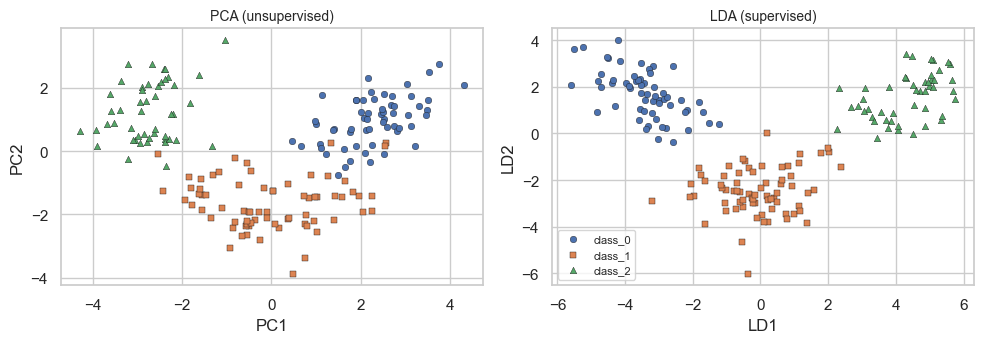

PCA chooses the direction of maximum VARIANCE without looking at the class.
LDA chooses the direction that best SEPARATES the classes, by maximising
the between-class scatter and minimising the within-class scatter.

Separation of the classes along the first axis:
         PCA PC1 mean  LDA LD1 mean
class_0         2.283        -3.422
class_1        -0.039        -0.080
class_2        -2.748         4.325


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for c, m in zip(range(3), ['o','s','^']):
    ax[0].scatter(X2[y==c,0], X2[y==c,1], marker=m, s=22, edgecolor='k', lw=.3,
                  label=wine.target_names[c])
    ax[1].scatter(X_lda[y==c,0], X_lda[y==c,1], marker=m, s=22, edgecolor='k', lw=.3,
                  label=wine.target_names[c])
ax[0].set_title('PCA (unsupervised)', fontsize=10); ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2')
ax[1].set_title('LDA (supervised)', fontsize=10); ax[1].set_xlabel('LD1'); ax[1].set_ylabel('LD2')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print('PCA chooses the direction of maximum VARIANCE without looking at the class.')
print('LDA chooses the direction that best SEPARATES the classes, by maximising')
print('the between-class scatter and minimising the within-class scatter.')
print('\nSeparation of the classes along the first axis:')
print(pd.DataFrame({'PCA PC1 mean': [X2[y==c,0].mean() for c in range(3)],
                    'LDA LD1 mean': [X_lda[y==c,0].mean() for c in range(3)]},
                   index=wine.target_names).round(3).to_string())

#### Step 3: Accuracy of a model built on the reduced data

In [13]:
Xtr, Xte, ytr, yte = train_test_split(X_sc, y, test_size=.3, random_state=RS, stratify=y)
print('Accuracy of a logistic regression built on the reduced data:\n')
rows = []
for name, red in [('No reduction (13 features)', None),
                  ('PCA - 2 components', PCA(n_components=2)),
                  ('LDA - 2 components', LDA(n_components=2))]:
    if red is None:
        A_tr, A_te = Xtr, Xte
    elif isinstance(red, PCA):
        A_tr = red.fit_transform(Xtr); A_te = red.transform(Xte)
    else:
        A_tr = red.fit_transform(Xtr, ytr); A_te = red.transform(Xte)
    m = LogisticRegression(max_iter=5000).fit(A_tr, ytr)
    rows.append([name, A_tr.shape[1], accuracy_score(yte, m.predict(A_te))])
print(pd.DataFrame(rows, columns=['Method','Features','Test accuracy']).round(4).to_string(index=False))
print('\nWith only two features LDA does better than PCA, because it used the class')
print('labels while building those two features.')

Accuracy of a logistic regression built on the reduced data:

                    Method  Features  Test accuracy
No reduction (13 features)        13         0.9815
        PCA - 2 components         2         0.9444
        LDA - 2 components         2         0.9815

With only two features LDA does better than PCA, because it used the class
labels while building those two features.


#### Step 4: LDA used as a classifier and the final comparison

In [14]:
# --- LDA can also be used directly as a classifier ---
clf = LDA().fit(Xtr, ytr)
print('LDA used as a classifier :')
print('   Training accuracy : %.4f' % clf.score(Xtr, ytr))
print('   Testing  accuracy : %.4f' % clf.score(Xte, yte))
print('   Prior probability of each class :', np.round(clf.priors_, 4))

print('\nSummary of the three techniques of this practical:\n')
summary = pd.DataFrame({
 'Point': ['Supervised or not','Basis of the method','Maximum components',
           'Can transform new data','Main use'],
 'PCA'  : ['Unsupervised','Maximum variance','number of features','Yes',
           'Compression and preprocessing'],
 't-SNE': ['Unsupervised','Neighbourhood probability','2 or 3','No','Visualisation'],
 'LDA'  : ['Supervised','Class separability','classes - 1','Yes',
           'Reduction before classification']})
print(summary.to_string(index=False))

LDA used as a classifier :
   Training accuracy : 1.0000
   Testing  accuracy : 0.9815
   Prior probability of each class : [0.3306 0.4032 0.2661]

Summary of the three techniques of this practical:

                 Point                           PCA                     t-SNE                             LDA
     Supervised or not                  Unsupervised              Unsupervised                      Supervised
   Basis of the method              Maximum variance Neighbourhood probability              Class separability
    Maximum components            number of features                    2 or 3                     classes - 1
Can transform new data                           Yes                        No                             Yes
              Main use Compression and preprocessing             Visualisation Reduction before classification


### Observations
- LDA reduced the thirteen features to **two linear discriminants**, and asking for a third one raised the error "n_components cannot be larger than min(n_features, n_classes - 1)", which confirms the limit of **c - 1 = 2 components for a 3-class problem**.
- The two discriminants explained **68.75% and 31.25%** of the between-class separation respectively.
- In the side-by-side plot the **LDA projection separated the three classes into three clearly distinct bands**, while the PCA projection, although good, left the groups closer together because PCA never looked at the labels.
- The class means along the first axis show this numerically: along **PC1** they were **2.283, -0.039 and -2.748**, while along **LD1** they were **-3.422, -0.080 and 4.325**, i.e. LDA pushed the two extreme classes much further apart.
- With only **two features, LDA gave a test accuracy of 0.9815, which is the same as using all 13 original features**, while **PCA with two components gave 0.9444**. LDA is better here because it used the labels while constructing those two features.
- Used directly as a classifier, LDA gave a **training accuracy of 1.0000 and a test accuracy of 0.9815**, with the class priors learned as **0.3306, 0.4032 and 0.2661**.

### Conclusion

In conclusion, Linear Discriminant Analysis was successfully implemented as a supervised dimensionality reduction technique and also as a classifier. It was observed that, unlike PCA, LDA uses the class labels and chooses the directions that maximise the between-class scatter while minimising the within-class scatter, so its projection separates the classes much better. It was also verified experimentally that LDA can produce at most (number of classes - 1) components, and that with only two such components the accuracy of the model equalled the accuracy obtained from all the original features, whereas PCA with two components was lower. The comparison of the three techniques showed that PCA is used for general compression and preprocessing, t-SNE for visualisation alone, and LDA for reducing the data before a classification task.